# Churn Analysis (EDA)


### 1. Dataset and Exploratory Analysis

First things first, we need to understand our dataset. This notebook will detail the exploratory analysis as well as the dataset.\
There are 21 columns about customer data, here is the detail of each column:\

**- customerID:** Unique ID for every customer;\
**- Gender:** Male or Female;\
**- SeniorCitizen:** Whether the customer is a senior citizen or not;\
**- Partner:** Whether the customer has a partner or not;\
**- Dependents:** Whether the customer has dependents or not;\
**- Tenure:** Number of months the customer stayed with company;\
**- PhoneService:** Whether the customer has a phone service or not;\
**- MultipleLines:** Whether the customer has multiple lines or not;\


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


df = pd.read_csv("/workspaces/churn-analysis/datasets/telco_customers.csv")

# Display the first few rows of the dataframe
df.head(3)

df = df.drop(['customerID'], axis=1)

In [48]:
# Standardizing column names: lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

#transforming totalcharges to numeric, coerce errors to 0
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
df.fillna({'totalcharges':0}, inplace=True)

categorical_cols = df.select_dtypes(include=['str']).columns
print(categorical_cols)

# Standardize categorical column values (replace spaces with underscores and convert to lowercase)
for col in categorical_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')



Index(['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod', 'churn'],
      dtype='str')


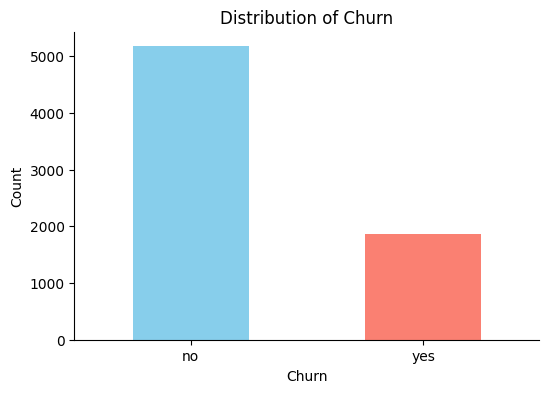

Global Churn Rate: 26.54%


In [49]:
#Plotting the distribution of target variable 'churn'
plt.figure(figsize=(6,4))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
df['churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

global_churn = df['churn'].value_counts(normalize=True)['yes']
print(f"Global Churn Rate: {global_churn:.2%}")

In [ ]:
for col in categorical_cols:
    print(f"Contigency table for {col}:")
    print(pd.crosstab(df[col], df['churn']))
    print("\n")
    print("Chi-square test results:")
    chi2, p, dof, ex = stats.chi2_contingency(pd.crosstab(df[col], df['churn']))
    print(f"Chi2: {chi2}, p-value: {p}")
    print("-" * 30)

Contigency table for gender:
churn     no  yes
gender           
female  2549  939
male    2625  930


Chi-square test results:
Chi2: 0.4840828822091383, p-value: 0.48657873605618596
------------------------------
Contigency table for partner:
churn      no   yes
partner            
no       2441  1200
yes      2733   669


Chi-square test results:
Chi2: 158.7333820309922, p-value: 2.1399113440759935e-36
------------------------------
Contigency table for dependents:
churn         no   yes
dependents            
no          3390  1543
yes         1784   326


Chi-square test results:
Chi2: 189.12924940423474, p-value: 4.9249216612154196e-43
------------------------------
Contigency table for phoneservice:
churn           no   yes
phoneservice            
no             512   170
yes           4662  1699


Chi-square test results:
Chi2: 0.9150329892546948, p-value: 0.3387825358066928
------------------------------
Contigency table for multiplelines:
churn               no  yes
multiplel

In [68]:
# Correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

corr = df[numerical_cols].corr()
corr.style.background_gradient(cmap='coolwarm')

,seniorcitizen,tenure,monthlycharges,totalcharges
seniorcitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
monthlycharges,0.220173,0.247900,1.000000,0.651174
totalcharges,0.103006,0.826178,0.651174,1.000000
